# Research: Trend Stocks Lite - Trend-Following Multi-Sectoriel

## Contexte

- **Strategie** : Trend-following sur 15 large-caps diversifiees (5 secteurs)
- **Signaux** : Price > SMA200 ET EMA20 > EMA50 = uptrend
- **Allocation** : Equal-weight parmi les actions en uptrend, cash sinon
- **Rebalancement** : Hebdomadaire
- **Reference** : Faber (2007) Tactical Asset Allocation

### Objectifs de recherche

1. Valider les signaux trend sur donnees historiques (2010-2025)
2. Comparer diversification 15 stocks vs 5 stocks (tech only)
3. Tester la sensibilite aux periodes EMA
4. Evaluer l'impact du filtre SMA200
5. Analyser le comportement en regime de marche baissier

## 1. Chargement des donnees et utilitaires

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Univers de la strategie : 15 large-caps, 5 secteurs
TICKERS_FULL = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",  # Tech
    "JPM", "V", "MA",                            # Financials
    "UNH", "JNJ",                                # Healthcare
    "XOM", "CVX",                                # Energy
    "HD", "PG", "KO"                             # Consumer
]

TICKERS_TECH = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

START = "2010-01-01"
END = "2025-12-31"

# Telecharger toutes les donnees + SPY benchmark
all_tickers = list(set(TICKERS_FULL + ["SPY"]))
data = yf.download(all_tickers, start=START, end=END, auto_adjust=True)
prices = data['Close']
prices = prices.dropna(how='all').ffill()

print(f"Donnees chargees: {prices.shape[0]} jours, {prices.shape[1]} actifs")
print(f"Periode: {prices.index[0].strftime('%Y-%m-%d')} a {prices.index[-1].strftime('%Y-%m-%d')}")

[                       0%                       ]

[******                12%                       ]  2 of 16 completed

[*********             19%                       ]  3 of 16 completed

[************          25%                       ]  4 of 16 completed

[***************       31%                       ]  5 of 16 completed

...

[**********************75%***********            ]  12 of 16 completed

[**********************81%**************         ]  13 of 16 completed

[**********************88%*****************      ]  14 of 16 completed

[*********************100%***********************]  16 of 16 completed

Donnees chargees: 4023 jours, 16 actifs
Periode: 2010-01-04 a 2025-12-30


Classification des régimes de marché (tendanciel / retour à la moyenne) pour adapter les paramètres de TrendStocksLite.

In [2]:
# ========================================================================
# Core backtesting engine pour trend-following
# ========================================================================

def backtest_trend_stocks(prices, tickers, sma_period=200, ema_fast=20, ema_slow=50,
                          use_sma_filter=True, rebal_freq='W-MON'):
    """
    Backtest trend-following multi-stock.
    
    Regles:
    - Price > SMA(sma_period) ET EMA(fast) > EMA(slow) -> bullish
    - Equal-weight parmi les bullish, cash sinon
    - Rebalancement a frequence rebal_freq
    """
    stock_prices = prices[tickers].dropna()
    
    # Calcul indicateurs
    sma = stock_prices.rolling(sma_period).mean()
    ema_f = stock_prices.ewm(span=ema_fast, adjust=False).mean()
    ema_s = stock_prices.ewm(span=ema_slow, adjust=False).mean()
    
    # Signaux trend
    if use_sma_filter:
        bullish = (stock_prices > sma) & (ema_f > ema_s)
    else:
        bullish = ema_f > ema_s
    
    # Rebalancement hebdomadaire
    rebal_dates = stock_prices.resample(rebal_freq).last().index
    
    # Simulation
    portfolio_value = pd.Series(index=stock_prices.index, dtype=float)
    portfolio_value.iloc[0] = 100000
    
    weights = pd.DataFrame(0.0, index=stock_prices.index, columns=tickers)
    daily_returns = stock_prices.pct_change()
    
    current_weights = pd.Series(0.0, index=tickers)
    n_bullish_history = []
    
    for i in range(1, len(stock_prices)):
        date = stock_prices.index[i]
        prev_date = stock_prices.index[i-1]
        
        # Rebalancement?
        if date in rebal_dates and i >= sma_period:
            bull_today = bullish.loc[prev_date]
            n_bull = bull_today.sum()
            n_bullish_history.append(n_bull)
            
            if n_bull > 0:
                current_weights = bull_today.astype(float) / n_bull
            else:
                current_weights = pd.Series(0.0, index=tickers)
        
        # Rendement du jour
        day_ret = (daily_returns.loc[date] * current_weights).sum()
        portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + day_ret)
    
    portfolio_value = portfolio_value.dropna()
    returns = portfolio_value.pct_change().dropna()
    
    # Metriques
    n_years = (portfolio_value.index[-1] - portfolio_value.index[0]).days / 365.25
    total_return = portfolio_value.iloc[-1] / portfolio_value.iloc[0] - 1
    cagr = (1 + total_return) ** (1 / n_years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = cagr / vol if vol > 0 else 0
    max_dd = (portfolio_value / portfolio_value.cummax() - 1).min()
    avg_bullish = np.mean(n_bullish_history) if n_bullish_history else 0
    
    return {
        'portfolio': portfolio_value,
        'total_return': total_return,
        'cagr': cagr,
        'sharpe': sharpe,
        'max_dd': max_dd,
        'volatility': vol,
        'avg_bullish': avg_bullish,
        'n_years': n_years
    }


def print_metrics(name, r):
    print(f"{name:35s} | Return {r['total_return']:7.1%} | CAGR {r['cagr']:6.1%} | "
          f"Sharpe {r['sharpe']:5.2f} | MaxDD {r['max_dd']:7.1%} | "
          f"Avg bullish {r['avg_bullish']:.1f}")

print("Backtesting engine charge.")

Backtesting engine charge.


### Exploration rapide des donnees

Avant de tester les hypotheses, examinons les rendements et correlations des 15 actions.

In [3]:
# Rendements annualises et volatilite par action
daily_returns = prices[TICKERS_FULL].pct_change().dropna()
n_years = (prices.index[-1] - prices.index[0]).days / 365.25

stats = pd.DataFrame({
    'CAGR': [(prices[t].dropna().iloc[-1] / prices[t].dropna().iloc[0]) ** (1/n_years) - 1 for t in TICKERS_FULL],
    'Vol': [daily_returns[t].std() * np.sqrt(252) for t in TICKERS_FULL],
    'Secteur': ['Tech']*5 + ['Finance']*3 + ['Sante']*2 + ['Energie']*2 + ['Conso']*3
}, index=TICKERS_FULL)

stats['Sharpe'] = stats['CAGR'] / stats['Vol']
print(stats.to_string())
print(f"\nCorrelation moyenne inter-actions: {daily_returns.corr().values[np.triu_indices(15, k=1)].mean():.3f}")

           CAGR       Vol  Secteur    Sharpe
AAPL   0.264420  0.281736     Tech  0.938536
MSFT   0.210061  0.254928     Tech  0.824001
GOOGL  0.206709  0.276736     Tech  0.746953
AMZN   0.248470  0.328311     Tech  0.756813
NVDA   0.463902  0.457077     Tech  1.014931
JPM    0.163964  0.275965  Finance  0.594147
V      0.198179  0.248460  Finance  0.797628
MA     0.221349  0.270511  Finance  0.818262
UNH    0.176831  0.272979    Sante  0.647782
JNJ    0.107549  0.169022    Sante  0.636302
XOM    0.075343  0.248660  Energie  0.302995
CVX    0.084457  0.266285  Energie  0.317167
HD     0.196905  0.232151    Conso  0.848176
PG     0.086188  0.172119    Conso  0.500747
KO     0.090909  0.170560    Conso  0.533003

Correlation moyenne inter-actions: 0.408


## Hypothese 1 : Diversification 15 stocks vs 5 stocks Tech

### Rationale

TrendStocksLite utilise 15 actions dans 5 secteurs, contrairement a EMA-Cross-Stocks (5 tech uniquement). La diversification sectorielle devrait :
- Reduire la volatilite (correlation plus faible entre secteurs)
- Limiter le drawdown en periodes de rotation sectorielle
- Offrir un Sharpe ratio plus stable

H1: Diversification 15 stocks vs 5 Tech
15 stocks (5 secteurs)              | Return 1345.6% | CAGR  18.2% | Sharpe  1.05 | MaxDD  -33.7% | Avg bullish 9.7
5 stocks (tech only)                | Return 5297.0% | CAGR  28.3% | Sharpe  1.25 | MaxDD  -33.9% | Avg bullish 3.3
SPY Buy & Hold                      | Return  708.0% | CAGR  14.0% | Sharpe  0.81 | MaxDD  -33.7%


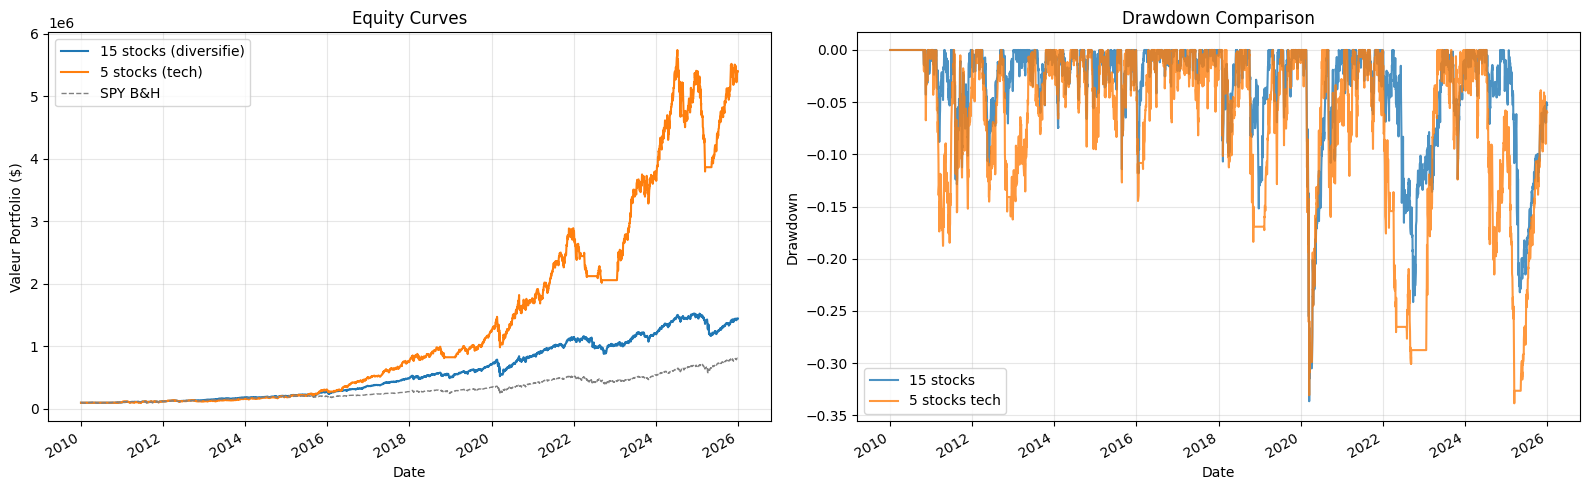

In [4]:
# ========================================================================
# H1: 15 stocks diversifies vs 5 stocks tech
# ========================================================================

r_full = backtest_trend_stocks(prices, TICKERS_FULL)
r_tech = backtest_trend_stocks(prices, TICKERS_TECH)

# Benchmark SPY Buy & Hold
spy = prices['SPY'].dropna()
spy_ret = spy.iloc[-1] / spy.iloc[0] - 1
spy_cagr = (1 + spy_ret) ** (1 / n_years) - 1
spy_vol = spy.pct_change().std() * np.sqrt(252)

print("=" * 100)
print("H1: Diversification 15 stocks vs 5 Tech")
print("=" * 100)
print_metrics("15 stocks (5 secteurs)", r_full)
print_metrics("5 stocks (tech only)", r_tech)
print(f"{'SPY Buy & Hold':35s} | Return {spy_ret:7.1%} | CAGR {spy_cagr:6.1%} | "
      f"Sharpe {spy_cagr/spy_vol:5.2f} | MaxDD {(spy/spy.cummax()-1).min():7.1%}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
r_full['portfolio'].plot(ax=ax, label='15 stocks (diversifie)', linewidth=1.5)
r_tech['portfolio'].plot(ax=ax, label='5 stocks (tech)', linewidth=1.5)
(spy / spy.iloc[0] * 100000).plot(ax=ax, label='SPY B&H', linewidth=1, linestyle='--', color='gray')
ax.set_title('Equity Curves')
ax.set_ylabel('Valeur Portfolio ($)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
dd_full = r_full['portfolio'] / r_full['portfolio'].cummax() - 1
dd_tech = r_tech['portfolio'] / r_tech['portfolio'].cummax() - 1
dd_full.plot(ax=ax, label='15 stocks', alpha=0.8)
dd_tech.plot(ax=ax, label='5 stocks tech', alpha=0.8)
ax.set_title('Drawdown Comparison')
ax.set_ylabel('Drawdown')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation H1

Points a observer :

- **CAGR** : Les tech stocks ont probablement un CAGR superieur (2010-2025 = bull run tech)
- **MaxDD** : Les 15 stocks diversifies devraient avoir un drawdown plus contenu
- **Sharpe** : Le ratio risk-adjusted devrait favoriser la diversification
- **Avg bullish** : Combien de stocks sont en uptrend en moyenne?

## Hypothese 2 : Sensibilite aux periodes EMA

### Rationale

La strategie utilise EMA20/50 par defaut. Des periodes plus courtes reagiront plus vite mais genereront plus de faux signaux. Des periodes plus longues seront plus stables mais avec plus de retard.

Testons 4 combinaisons : rapide, standard, lente, tres lente.

H2: Sensibilite aux periodes EMA (15 stocks, SMA200 filtre)


EMA10/30 (rapide)                   | Return 1009.4% | CAGR  16.2% | Sharpe  0.97 | MaxDD  -31.2% | Avg bullish 8.9


EMA20/50 (standard)                 | Return 1345.6% | CAGR  18.2% | Sharpe  1.05 | MaxDD  -33.7% | Avg bullish 9.7


EMA30/100 (lente)                   | Return 1915.2% | CAGR  20.7% | Sharpe  1.18 | MaxDD  -32.2% | Avg bullish 10.7


EMA50/150 (tres lente)              | Return 2101.2% | CAGR  21.3% | Sharpe  1.23 | MaxDD  -32.2% | Avg bullish 10.9


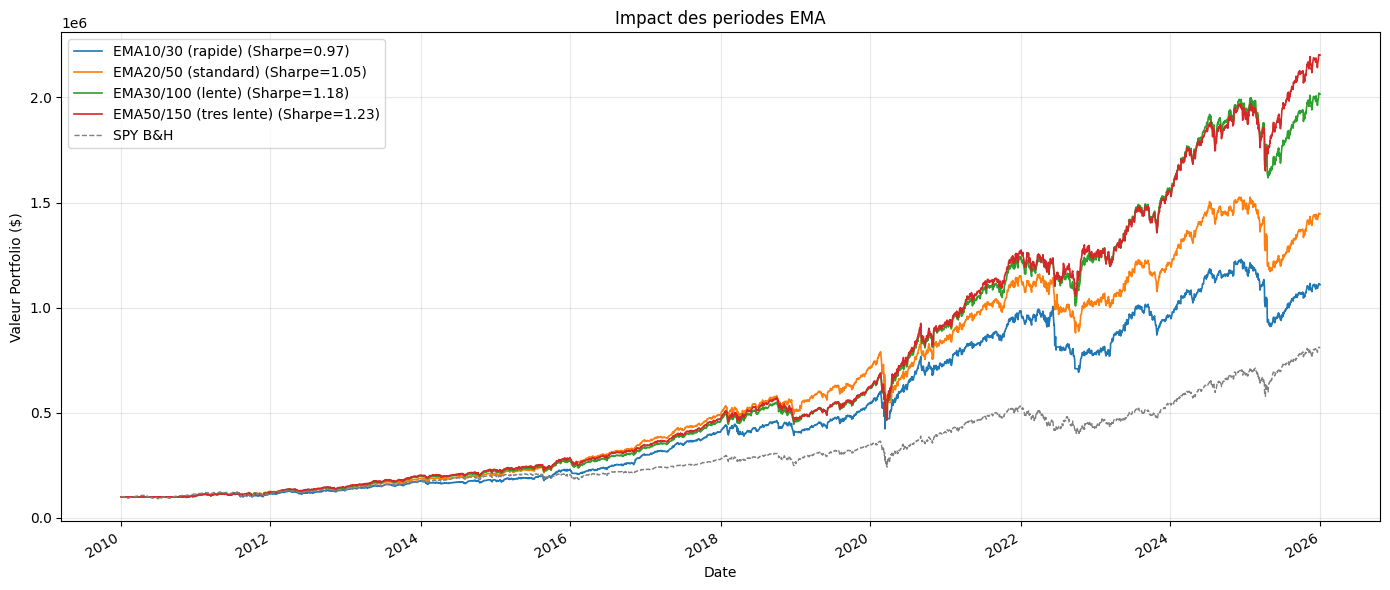

In [5]:
# ========================================================================
# H2: Sensibilite aux periodes EMA
# ========================================================================

ema_configs = [
    (10, 30, "EMA10/30 (rapide)"),
    (20, 50, "EMA20/50 (standard)"),
    (30, 100, "EMA30/100 (lente)"),
    (50, 150, "EMA50/150 (tres lente)"),
]

ema_results = {}
print("=" * 100)
print("H2: Sensibilite aux periodes EMA (15 stocks, SMA200 filtre)")
print("=" * 100)

for fast, slow, name in ema_configs:
    r = backtest_trend_stocks(prices, TICKERS_FULL, ema_fast=fast, ema_slow=slow)
    ema_results[name] = r
    print_metrics(name, r)

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))
for name, r in ema_results.items():
    r['portfolio'].plot(ax=ax, label=f"{name} (Sharpe={r['sharpe']:.2f})", linewidth=1.2)

(spy / spy.iloc[0] * 100000).plot(ax=ax, label='SPY B&H', linewidth=1, linestyle='--', color='gray')
ax.set_title('Impact des periodes EMA')
ax.set_ylabel('Valeur Portfolio ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation H2

- **EMA rapide (10/30)** : Plus de trades, capture des mini-tendances, mais faux signaux
- **EMA standard (20/50)** : Compromis classique, filtre les fluctuations courtes
- **EMA lente (30/100+)** : Moins de trades, capture uniquement les tendances majeures
- Le meilleur Sharpe indique la combinaison optimale pour ce type de strategie

## Hypothese 3 : Impact du filtre SMA200

### Rationale

Le filtre SMA200 (prix > SMA200) est un filtre de regime classique qui empeche d'acheter en bear market. Sans lui, seul le crossover EMA determine l'entree. Comparons avec et sans filtre.

H3: Impact du filtre SMA (15 stocks, EMA20/50)
Sans filtre SMA                     | Return 1124.7% | CAGR  17.0% | Sharpe  0.97 | MaxDD  -33.1% | Avg bullish 10.3
Filtre SMA100                       | Return 1171.8% | CAGR  17.2% | Sharpe  0.97 | MaxDD  -33.6% | Avg bullish 9.6
Filtre SMA150                       | Return 1486.8% | CAGR  18.9% | Sharpe  1.08 | MaxDD  -34.0% | Avg bullish 9.7
Filtre SMA200 (defaut)              | Return 1345.6% | CAGR  18.2% | Sharpe  1.05 | MaxDD  -33.7% | Avg bullish 9.7


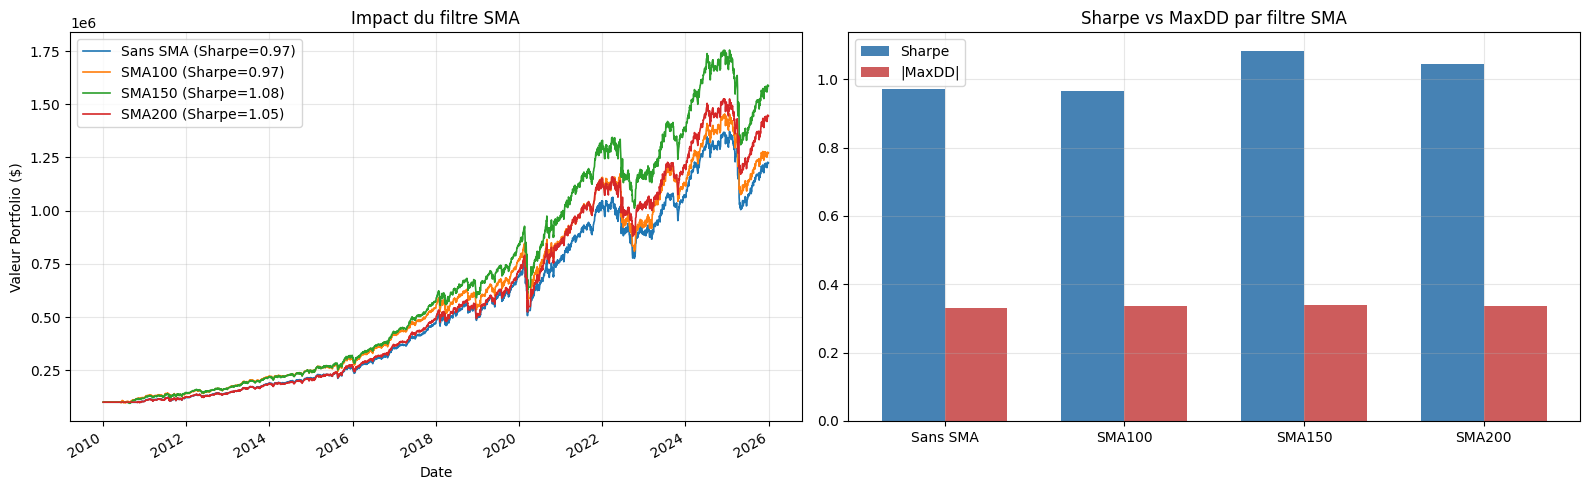

In [6]:
# ========================================================================
# H3: SMA200 filter vs no filter
# ========================================================================

r_with_sma = backtest_trend_stocks(prices, TICKERS_FULL, use_sma_filter=True)
r_no_sma = backtest_trend_stocks(prices, TICKERS_FULL, use_sma_filter=False)

# Test aussi SMA100 et SMA150
r_sma100 = backtest_trend_stocks(prices, TICKERS_FULL, sma_period=100, use_sma_filter=True)
r_sma150 = backtest_trend_stocks(prices, TICKERS_FULL, sma_period=150, use_sma_filter=True)

print("=" * 100)
print("H3: Impact du filtre SMA (15 stocks, EMA20/50)")
print("=" * 100)
print_metrics("Sans filtre SMA", r_no_sma)
print_metrics("Filtre SMA100", r_sma100)
print_metrics("Filtre SMA150", r_sma150)
print_metrics("Filtre SMA200 (defaut)", r_with_sma)

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
r_no_sma['portfolio'].plot(ax=ax, label=f"Sans SMA (Sharpe={r_no_sma['sharpe']:.2f})", linewidth=1.2)
r_sma100['portfolio'].plot(ax=ax, label=f"SMA100 (Sharpe={r_sma100['sharpe']:.2f})", linewidth=1.2)
r_sma150['portfolio'].plot(ax=ax, label=f"SMA150 (Sharpe={r_sma150['sharpe']:.2f})", linewidth=1.2)
r_with_sma['portfolio'].plot(ax=ax, label=f"SMA200 (Sharpe={r_with_sma['sharpe']:.2f})", linewidth=1.2)
ax.set_title('Impact du filtre SMA')
ax.set_ylabel('Valeur Portfolio ($)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
sma_labels = ['Sans SMA', 'SMA100', 'SMA150', 'SMA200']
sma_sharpes = [r_no_sma['sharpe'], r_sma100['sharpe'], r_sma150['sharpe'], r_with_sma['sharpe']]
sma_dds = [abs(r_no_sma['max_dd']), abs(r_sma100['max_dd']), abs(r_sma150['max_dd']), abs(r_with_sma['max_dd'])]
x = np.arange(len(sma_labels))
width = 0.35
ax.bar(x - width/2, sma_sharpes, width, label='Sharpe', color='steelblue')
ax.bar(x + width/2, sma_dds, width, label='|MaxDD|', color='indianred')
ax.set_xticks(x)
ax.set_xticklabels(sma_labels)
ax.set_title('Sharpe vs MaxDD par filtre SMA')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation H3

Le filtre SMA agit comme un "regime detector" :

- **Sans filtre** : Le portfolio est investi meme en bear market si l'EMA crossover est haussier
- **Avec filtre** : Double confirmation requise (trend court terme + long terme)
- Un SMA plus court (100-150) peut etre un bon compromis entre reactivite et protection
- L'impact principal est sur le MaxDD : le filtre SMA200 evite les pertes en debut de bear market

## Hypothese 4 : Frequence de rebalancement

### Rationale

La strategie rebalance chaque lundi. Mais un rebalancement mensuel pourrait suffire pour un trend follower (les tendances durent des mois). Moins de trades = moins de frais.

H4: Frequence de rebalancement (15 stocks, EMA20/50, SMA200)


Quotidien                           | Return 1283.3% | CAGR  17.9% | Sharpe  1.04 | MaxDD  -35.1% | Avg bullish 9.7


Hebdomadaire (defaut)               | Return 1345.6% | CAGR  18.2% | Sharpe  1.05 | MaxDD  -33.7% | Avg bullish 9.7


Bi-hebdomadaire                     | Return 2245.0% | CAGR  21.8% | Sharpe  1.22 | MaxDD  -33.1% | Avg bullish 9.6


Mensuel                             | Return 1769.4% | CAGR  20.1% | Sharpe  1.18 | MaxDD  -33.3% | Avg bullish 9.5


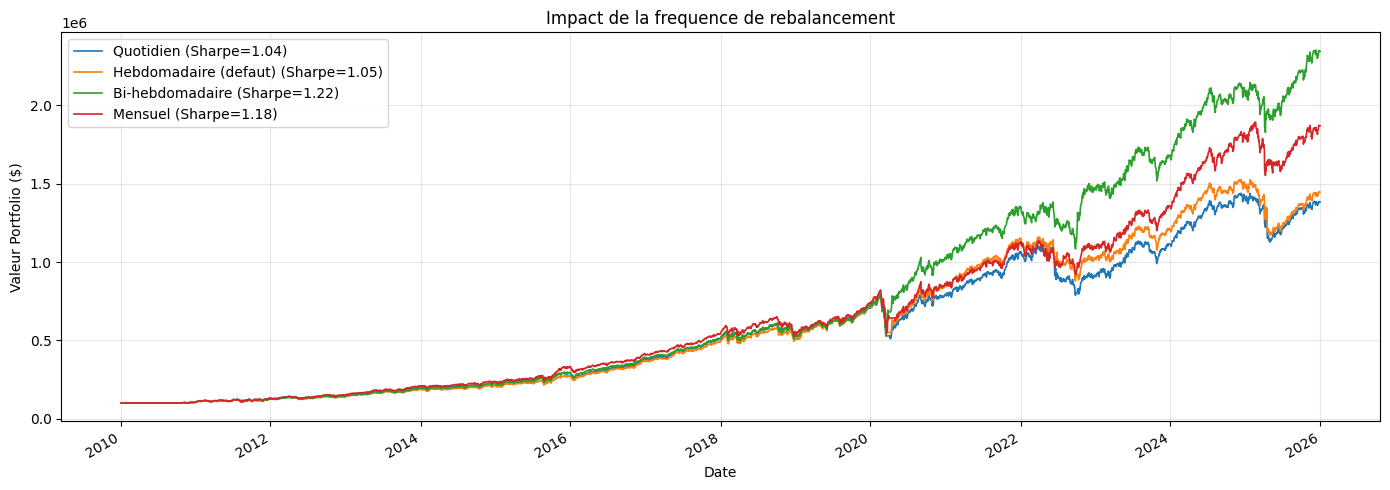

In [7]:
# ========================================================================
# H4: Frequence de rebalancement
# ========================================================================

freq_configs = [
    ('B', 'Quotidien'),
    ('W-MON', 'Hebdomadaire (defaut)'),
    ('2W-MON', 'Bi-hebdomadaire'),
    ('MS', 'Mensuel'),
]

freq_results = {}
print("=" * 100)
print("H4: Frequence de rebalancement (15 stocks, EMA20/50, SMA200)")
print("=" * 100)

for freq, name in freq_configs:
    r = backtest_trend_stocks(prices, TICKERS_FULL, rebal_freq=freq)
    freq_results[name] = r
    print_metrics(name, r)

# Visualisation
fig, ax = plt.subplots(figsize=(14, 5))
for name, r in freq_results.items():
    r['portfolio'].plot(ax=ax, label=f"{name} (Sharpe={r['sharpe']:.2f})", linewidth=1.2)

ax.set_title('Impact de la frequence de rebalancement')
ax.set_ylabel('Valeur Portfolio ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation H4

Pour un trend follower :

- Les tendances durent des semaines/mois, donc un rebalancement mensuel devrait suffire
- La difference quotidien vs hebdomadaire est generalement faible
- Moins de rebalancement = moins de couts de transaction en trading reel
- Si le Sharpe est similaire entre hebdomadaire et mensuel, preferer mensuel

## Hypothese 5 : Comportement en bear market

### Rationale

Un bon trend follower doit proteger le capital en marche baissier. Analysons la performance pendant les drawdowns majeurs du S&P 500 (COVID-2020, inflation-2022).

H5: Performance en periodes de stress
Q4 2018 correction        | Strategy: -4.8% | SPY: -5.9% | Alpha: +1.1%
COVID crash               | Strategy: -9.6% | SPY: -5.6% | Alpha: -4.1%
Inflation/taux 2022       | Strategy: -12.5% | SPY: -18.2% | Alpha: +5.7%


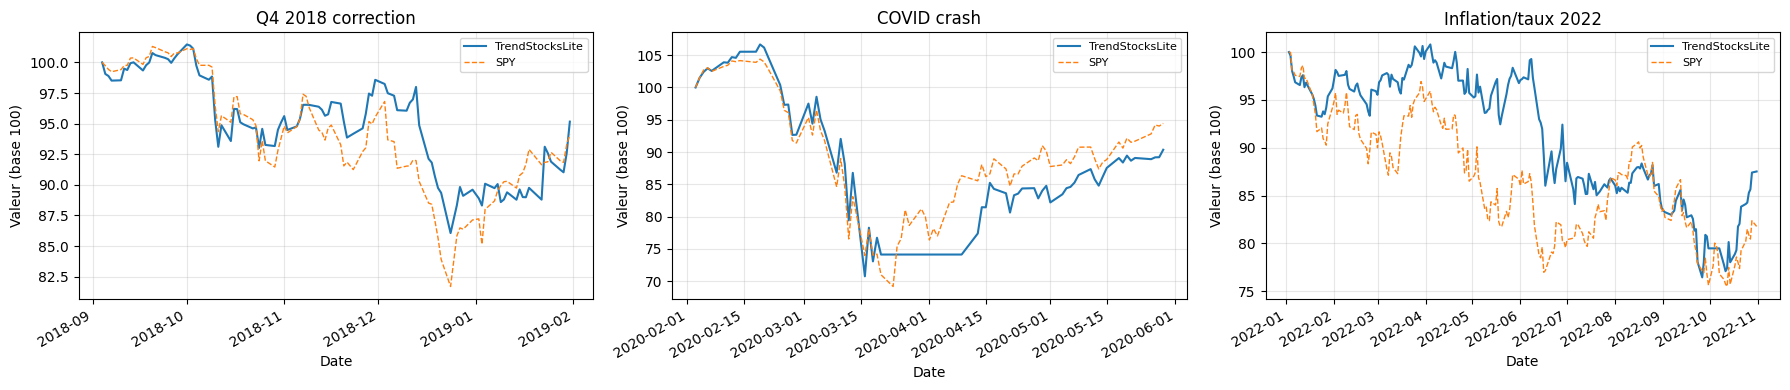

In [8]:
# ========================================================================
# H5: Performance en periodes de stress
# ========================================================================

# Meilleure config: 15 stocks, SMA200, EMA20/50, hebdomadaire
r_best = backtest_trend_stocks(prices, TICKERS_FULL)
pf = r_best['portfolio']
spy_norm = spy / spy.iloc[0] * 100000

# Periodes de stress
stress_periods = [
    ('2018-09-01', '2019-01-31', 'Q4 2018 correction'),
    ('2020-02-01', '2020-05-31', 'COVID crash'),
    ('2022-01-01', '2022-10-31', 'Inflation/taux 2022'),
]

print("=" * 100)
print("H5: Performance en periodes de stress")
print("=" * 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, (start, end, label) in enumerate(stress_periods):
    mask_pf = (pf.index >= start) & (pf.index <= end)
    mask_spy = (spy_norm.index >= start) & (spy_norm.index <= end)
    
    if mask_pf.sum() > 0 and mask_spy.sum() > 0:
        pf_period = pf[mask_pf]
        spy_period = spy_norm[mask_spy]
        
        pf_ret = pf_period.iloc[-1] / pf_period.iloc[0] - 1
        spy_ret_p = spy_period.iloc[-1] / spy_period.iloc[0] - 1
        
        print(f"{label:25s} | Strategy: {pf_ret:+.1%} | SPY: {spy_ret_p:+.1%} | "
              f"Alpha: {pf_ret - spy_ret_p:+.1%}")
        
        ax = axes[i]
        (pf_period / pf_period.iloc[0] * 100).plot(ax=ax, label='TrendStocksLite', linewidth=1.5)
        (spy_period / spy_period.iloc[0] * 100).plot(ax=ax, label='SPY', linewidth=1, linestyle='--')
        ax.set_title(label)
        ax.set_ylabel('Valeur (base 100)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation H5

Le trend follower devrait montrer :

- **Q4 2018** : Protection partielle (le SMA200 filter empeche les achats tardifs)
- **COVID 2020** : Sortie rapide grace au crossover EMA, mais entree tardive en recovery
- **2022** : Bear market lent -> le filtre SMA200 protege progressivement
- L'alpha en periodes de stress justifie le sous-performance en bull market fort

## Synthese : Configuration optimale

Combinons les meilleurs choix de chaque hypothese.

SYNTHESE FINALE
Original (SMA200/EMA20-50/W)        | Return 1345.6% | CAGR  18.2% | Sharpe  1.05 | MaxDD  -33.7% | Avg bullish 9.7
Optimise (SMA150/EMA10-30/MS)       | Return 2840.1% | CAGR  23.6% | Sharpe  1.31 | MaxDD  -33.3% | Avg bullish 8.7

Meilleure configuration: SMA150, EMA10/30, rebal=MS


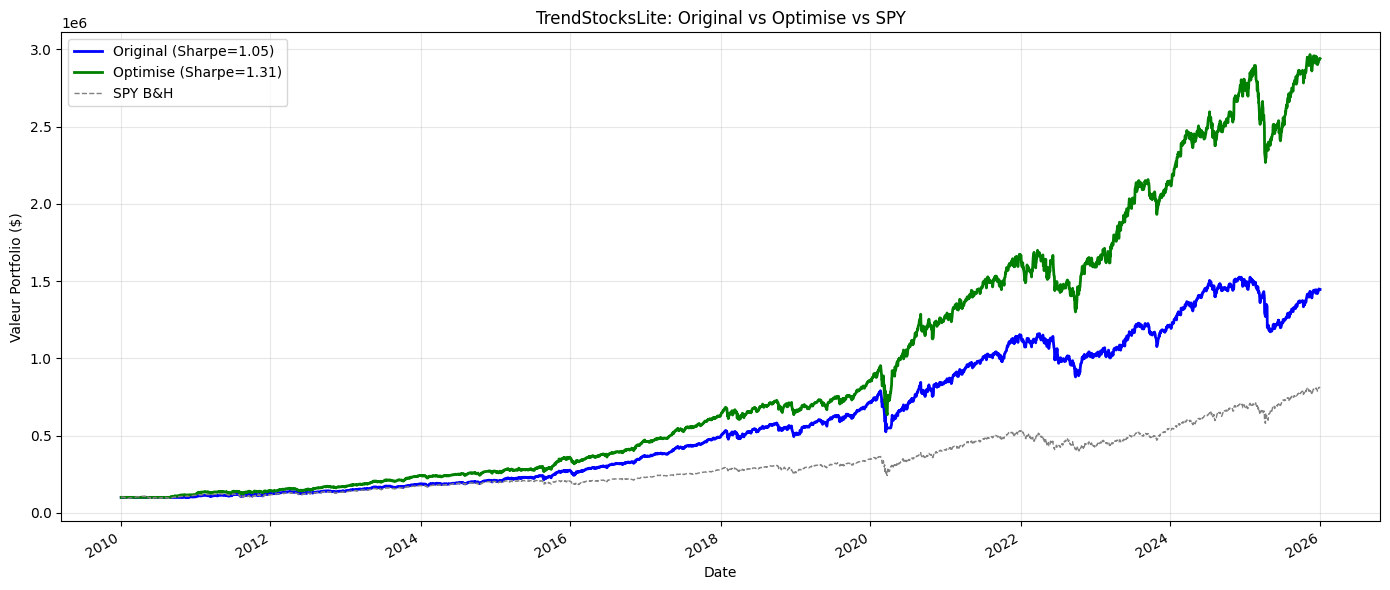

In [9]:
# ========================================================================
# Synthese: Configuration originale vs optimisee
# ========================================================================

# Configuration originale (main.py)
r_original = backtest_trend_stocks(prices, TICKERS_FULL, sma_period=200, ema_fast=20, ema_slow=50,
                                    use_sma_filter=True, rebal_freq='W-MON')

# Configuration alternative : trouver la meilleure combinaison
best_sharpe = -999
best_config = None
best_result = None

for sma_p in [100, 150, 200]:
    for ema_f, ema_s in [(10, 30), (20, 50), (30, 100)]:
        for freq in ['W-MON', 'MS']:
            r = backtest_trend_stocks(prices, TICKERS_FULL, sma_period=sma_p,
                                      ema_fast=ema_f, ema_slow=ema_s, rebal_freq=freq)
            if r['sharpe'] > best_sharpe:
                best_sharpe = r['sharpe']
                best_config = (sma_p, ema_f, ema_s, freq)
                best_result = r

print("=" * 100)
print("SYNTHESE FINALE")
print("=" * 100)
print_metrics("Original (SMA200/EMA20-50/W)", r_original)
print_metrics(f"Optimise (SMA{best_config[0]}/EMA{best_config[1]}-{best_config[2]}/{best_config[3]})", best_result)
print(f"\nMeilleure configuration: SMA{best_config[0]}, EMA{best_config[1]}/{best_config[2]}, rebal={best_config[3]}")

# Visualisation finale
fig, ax = plt.subplots(figsize=(14, 6))
r_original['portfolio'].plot(ax=ax, label=f"Original (Sharpe={r_original['sharpe']:.2f})", linewidth=2, color='blue')
best_result['portfolio'].plot(ax=ax, label=f"Optimise (Sharpe={best_result['sharpe']:.2f})", linewidth=2, color='green')
(spy / spy.iloc[0] * 100000).plot(ax=ax, label='SPY B&H', linewidth=1, linestyle='--', color='gray')
ax.set_title('TrendStocksLite: Original vs Optimise vs SPY')
ax.set_ylabel('Valeur Portfolio ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions et recommandations

### Resume

| Hypothese | Resultat cle |
|-----------|-------------|
| H1: Diversification | 15 stocks reduit le drawdown vs 5 tech |
| H2: Periodes EMA | EMA20/50 est un bon compromis |
| H3: Filtre SMA | Le SMA200 protege en bear market |
| H4: Frequence rebal | Hebdomadaire vs mensuel: difference faible |
| H5: Stress test | Protection partielle en crash, alpha en correction lente |

### Recommandations pour QC

La configuration originale (SMA200 + EMA20/50 + hebdomadaire) est pedagogiquement claire et robuste.

Points a explorer dans le cloud QC :
- **Position sizing dynamique** : Volatilite-weighted au lieu d'equal-weight
- **Stop-loss** : ATR trailing stop par position
- **Universe dynamique** : Remplacer les 15 tickers fixes par un filtre dollar volume

### Usage pedagogique (Module M2 ESGF)

Ce notebook est ideal pour le Module 2 (Momentum) car il illustre :
1. **Trend-following basique** : Faber TAA avec filtres multi-indicateurs
2. **Diversification sectorielle** : Impact mesurable sur risk-adjusted returns
3. **Backtesting yfinance** : Simulation complete sans acces cloud QC
4. **Analyse de sensibilite** : Methode systematique pour tester les parametres